In [1]:
%pip install -q pandas numpy matplotlib scipy pyyaml ipywidgets

Note: you may need to restart the kernel to use updated packages.


# Extended Analysis: AlphaReQ

**Research question:** *Do AlphaReQ (α) trajectory features during pre-training predict downstream multilingual performance? Specifically: do per-language α values and the live geometry-performance alignment correlate with accuracy and grokking behaviour on m-MMLU, XCOPA, Belebele, and M-ARC?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages) · Belebele (5-shot, 10 languages) · M-ARC (5-shot, 9 languages) — configured in `code/downstream_evaluation/configs/benchmarks.yaml`  
**Geometry source:** `fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`

### What this notebook does

1. **Layer selection** — measures cross-language AlphaReQ stratification at each layer to identify the most informative layer. Layer 21 is used for FuxiTranyu-8B and layer 19 for Apertus-8B-2509 — the same layers as the RankMe analysis, enabling direct comparison between the two metrics.

2. **AlphaReQ trajectory analysis** — for each language, computes point-in-time α values and non-overlapping quartile means (Q2 25–50%, Q3 50–75%, Q4 75–100%) from the AlphaReQ trajectory at the selected layer. Parallel to the RankMe analysis.

3. **Grokking detection** — finds the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints. Separately per task and language.

4. **Overlay plots** — dual-axis plots overlaying the AlphaReQ trajectory and accuracy curve per language, with grokking onset marked. One plot per task (m-MMLU, XCOPA, Belebele, M-ARC).

5. **Predictor correlation analysis** — tests seven AlphaReQ predictors against two outcomes (grokking onset, peak accuracy) using Spearman and Pearson correlations. Grokking onset uses only AlphaReQ at the first checkpoint (at or before grokking onset); peak accuracy uses all seven predictors. Computed separately per task, never pooled across tasks.

6. **Per-checkpoint cross-language correlation** — at every training checkpoint, computes the Spearman rank correlation between AlphaReQ and accuracy *across languages*, yielding a trajectory that shows when and how strongly the α geometry tracks the live language performance hierarchy.

In [2]:
import warnings

import pandas as pd

from utils import (
    load_config, init_models,
    load_rankme_data, load_eval_data, load_model_data,
    compute_alpha_phases, compute_and_show_alpha_phases,
    compute_grokking, compute_and_show_grokking,
    compute_alpha_correlations_table, compute_and_show_alpha_correlations,
    compute_checkpoint_correlations, compute_and_show_checkpoint_correlations,
    show_stratification,
    plot_alpha_phases, show_alpha_phases,
    show_alpha_overlay_widget,
    show_alpha_correlation_heatmap,
    show_predictor_scatter,
    plot_checkpoint_correlations, show_checkpoint_correlations,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

The notebook analyses **both models simultaneously**. `init_models()` loads config, colors, and benchmark metadata from `configs/benchmarks.yaml` for each model.

In [3]:
MODELS, data = init_models()

[fuxi] FuxiTranyu-8B  |  Layer: layer_21  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_19  |  Aggregation: last


## Layer Selection

AlphaReQ is computed at every layer and checkpoint, but the phase and correlation analyses require choosing one representative layer per model. To select the most informative layer, we measure the **cross-language AlphaReQ stratification signal** at each layer: for each language we average AlphaReQ across the **first 10 training checkpoints**, then compute the standard deviation of those per-language averages across languages. Using only the first 10 checkpoints is consistent with the layer selection approach used in the RankMe analysis.

**A high standard deviation means the layer separates languages strongly** in terms of α geometry — this is the layer with the most signal for predicting per-language downstream outcomes.

The figure below shows this stratification signal across all layers for both models. The selected layer (peak std) is marked with a coloured dashed line.

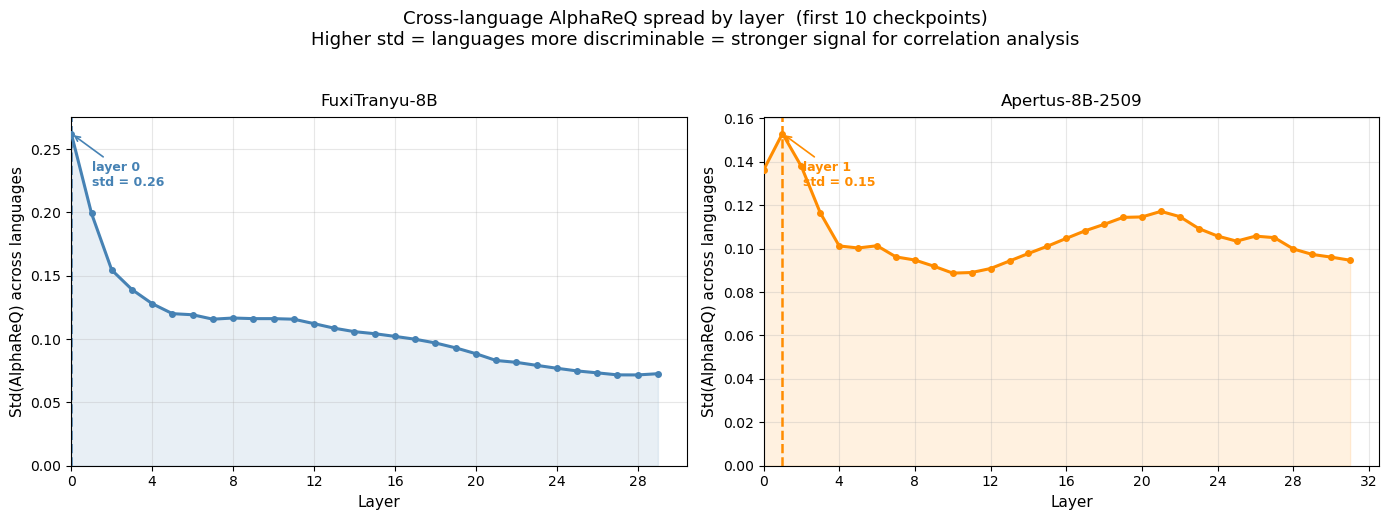

Saved: plots_joao_pinto_407597/alpha_req_layer_stratification.png


In [4]:
show_stratification(MODELS, data, metric="alpha_req", n_first_checkpoints=10)

### Selected layers

- **FuxiTranyu-8B → layer 21**: the same layer as the RankMe analysis. The AlphaReQ stratification signal decreases monotonically across layers (no natural peak), so we adopt the RankMe-selected layer to maintain consistency and allow direct comparison between the two metrics.
- **Apertus-8B-2509 → layer 19**: the same layer as the RankMe analysis.

These are the layers used throughout this notebook for all AlphaReQ correlation and per-checkpoint analyses.

## Data

Two sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — geometry metrics for all checkpoints, all languages, and all layers. Used for layer selection, trajectory plots, and per-checkpoint correlation.

- **`fuxi_fine_wiki_mmlu_xcopa_belebele_marc_layer15_merged.csv` / `apertus_fine_wiki_mmlu_xcopa_belebele_marc_layer21_merged.csv`** — downstream accuracy for all four benchmarks merged with geometry at the selected layer. Used for grokking detection, correlation analysis, and overlay plots.

In [5]:
load_model_data(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
Loaded geometry data: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_21, agg=last → 798 rows
Loaded eval: 1824 records — 4 task(s), 57 checkpoint(s)

── Apertus-8B-2509 ────────────────────────────────────────
Loaded geometry data: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_19, agg=last → 616 rows
Loaded eval: 1408 records — 4 task(s), 44 checkpoint(s)


## AlphaReQ Trajectories

The table below summarises key AlphaReQ (α) geometry metrics per language, derived from the α trajectory at the working layer:

- **AlphaReQ first checkpoint** — α value at the first observed checkpoint.
- **AlphaReQ checkpoint 10** — α value at the 10th checkpoint (the layer-selection horizon).
- **mean first 10 checkpoints** — mean α over the first 10 checkpoints (the layer-selection window).
- **mean Q2 (25–50%)** — mean α over checkpoints in the second quartile of the token range.
- **mean Q3 (50–75%)** — mean α over checkpoints in the third quartile of the token range.
- **mean Q4 (75–100%)** — mean α over checkpoints in the last quartile of the token range.
- **AlphaReQ last checkpoint** — α value at the end of training.

The three quartile windows are non-overlapping by design, ensuring each captures a genuinely distinct phase of training.

In [6]:
compute_and_show_alpha_phases(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
  language  AlphaReQ first checkpoint  AlphaReQ checkpoint 10  mean first 10 checkpoints  mean Q2 (25–50%)  mean Q3 (50–75%)  mean Q4 (75–100%)  AlphaReQ last checkpoint
    Arabic                   0.787631                0.775016                   0.777081          0.756668          0.741440           0.740667                  0.729904
   Chinese                   0.709994                0.687757                   0.689040          0.686634          0.683285           0.683123                  0.679283
   English                   0.641096                0.600519                   0.605627          0.604177          0.606451           0.607801                  0.607061
   Finnish                   0.669112                0.630683                   0.635271          0.633914          0.638782           0.639297                  0.637063
    French                   0.653118                0.615872                   0.620612   

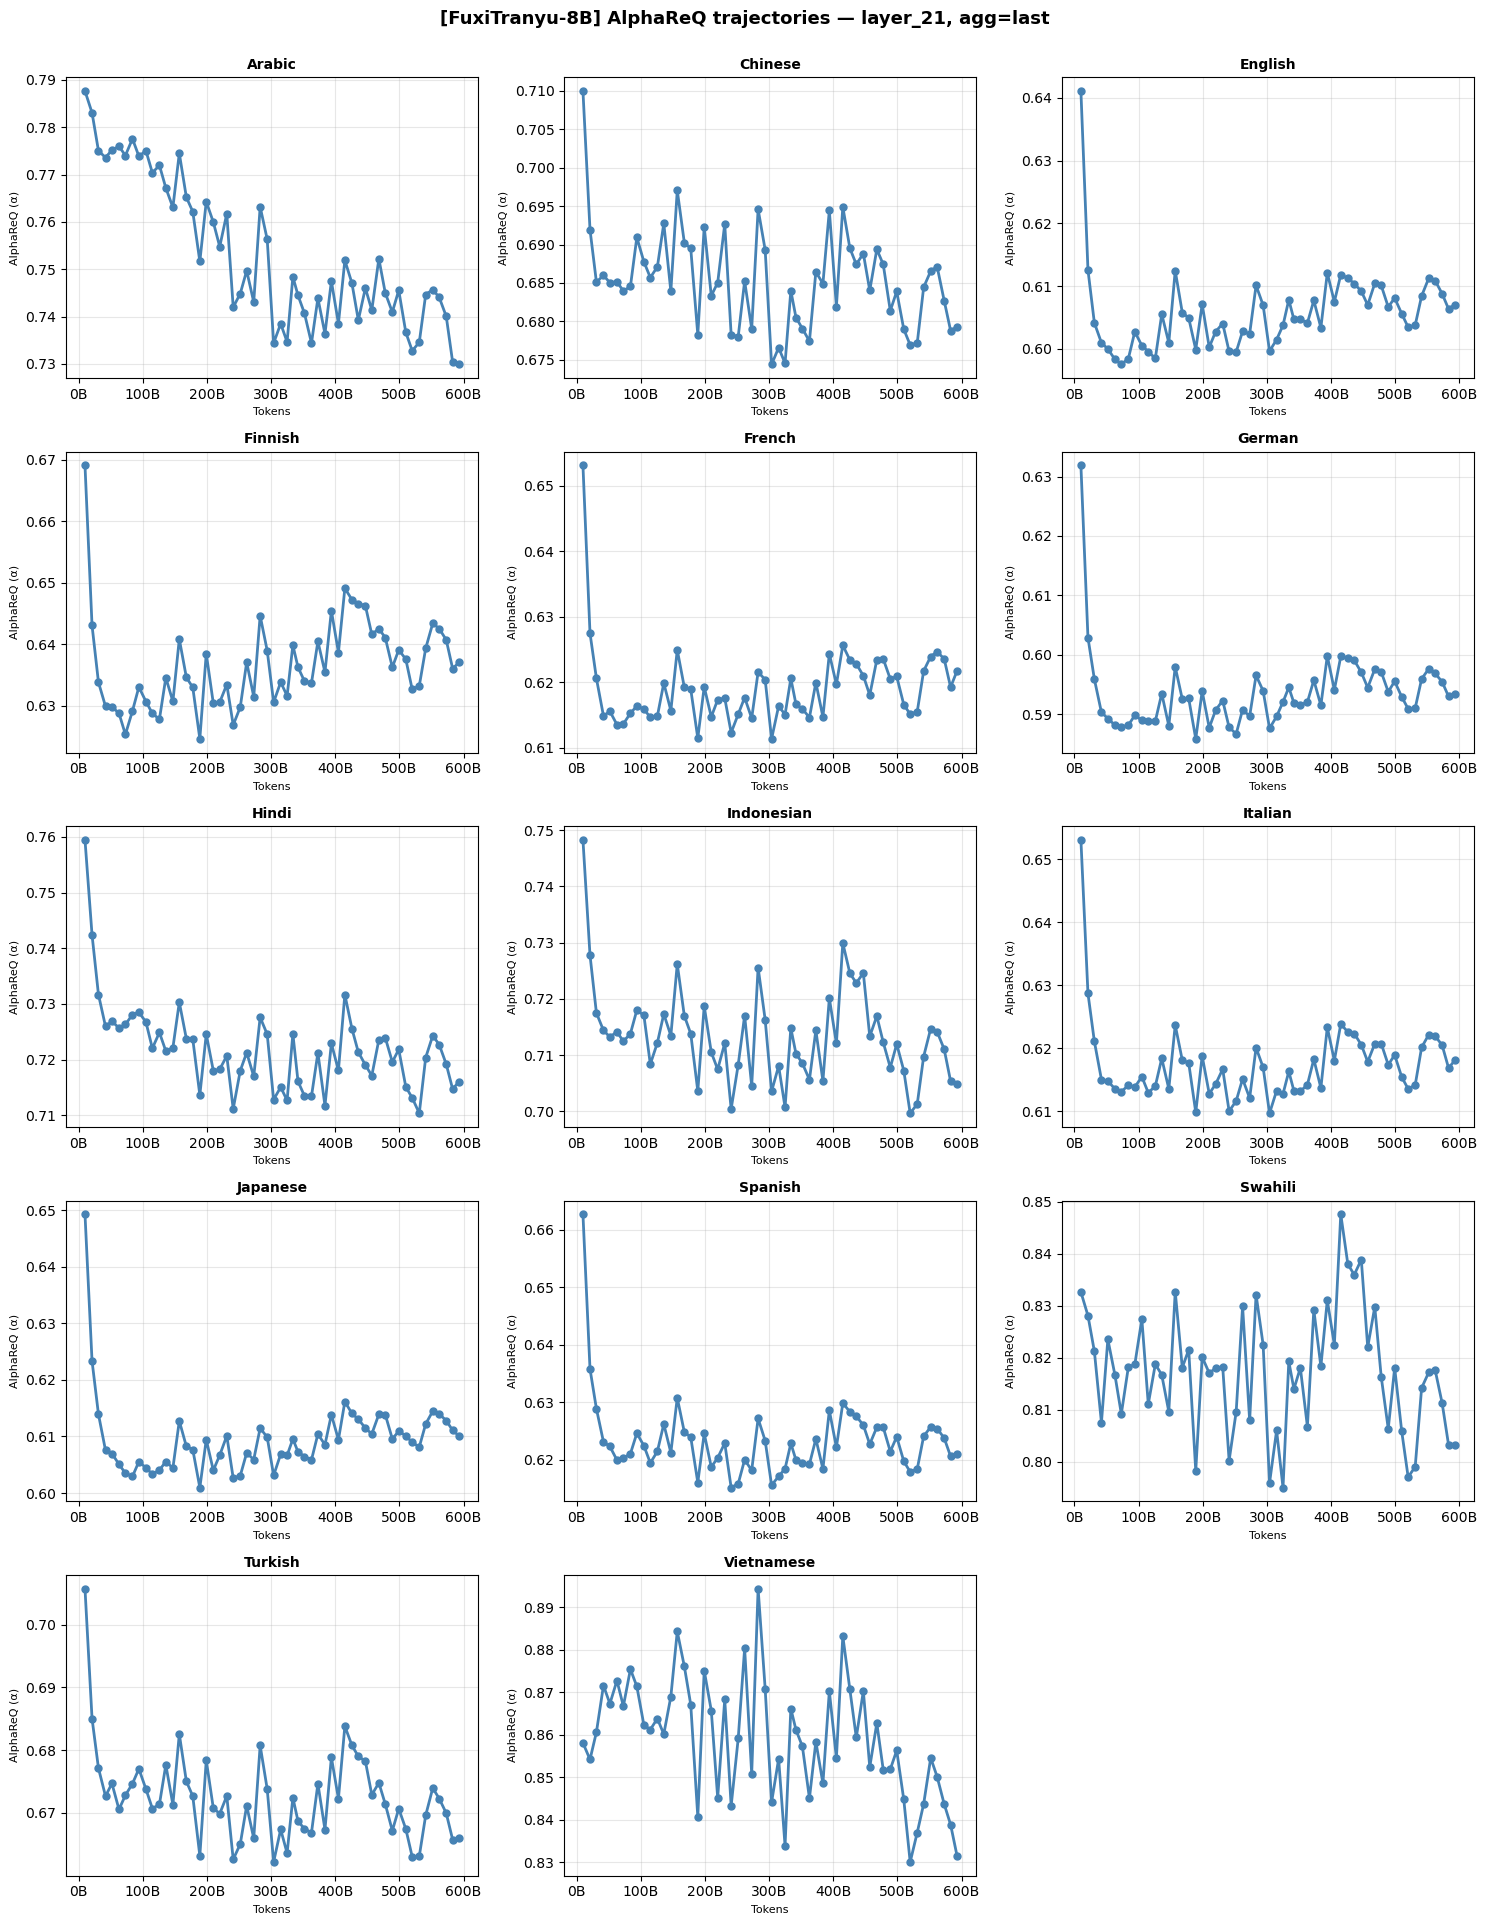

Saved: plots_joao_pinto_407597/alpha_phases_fuxi.png


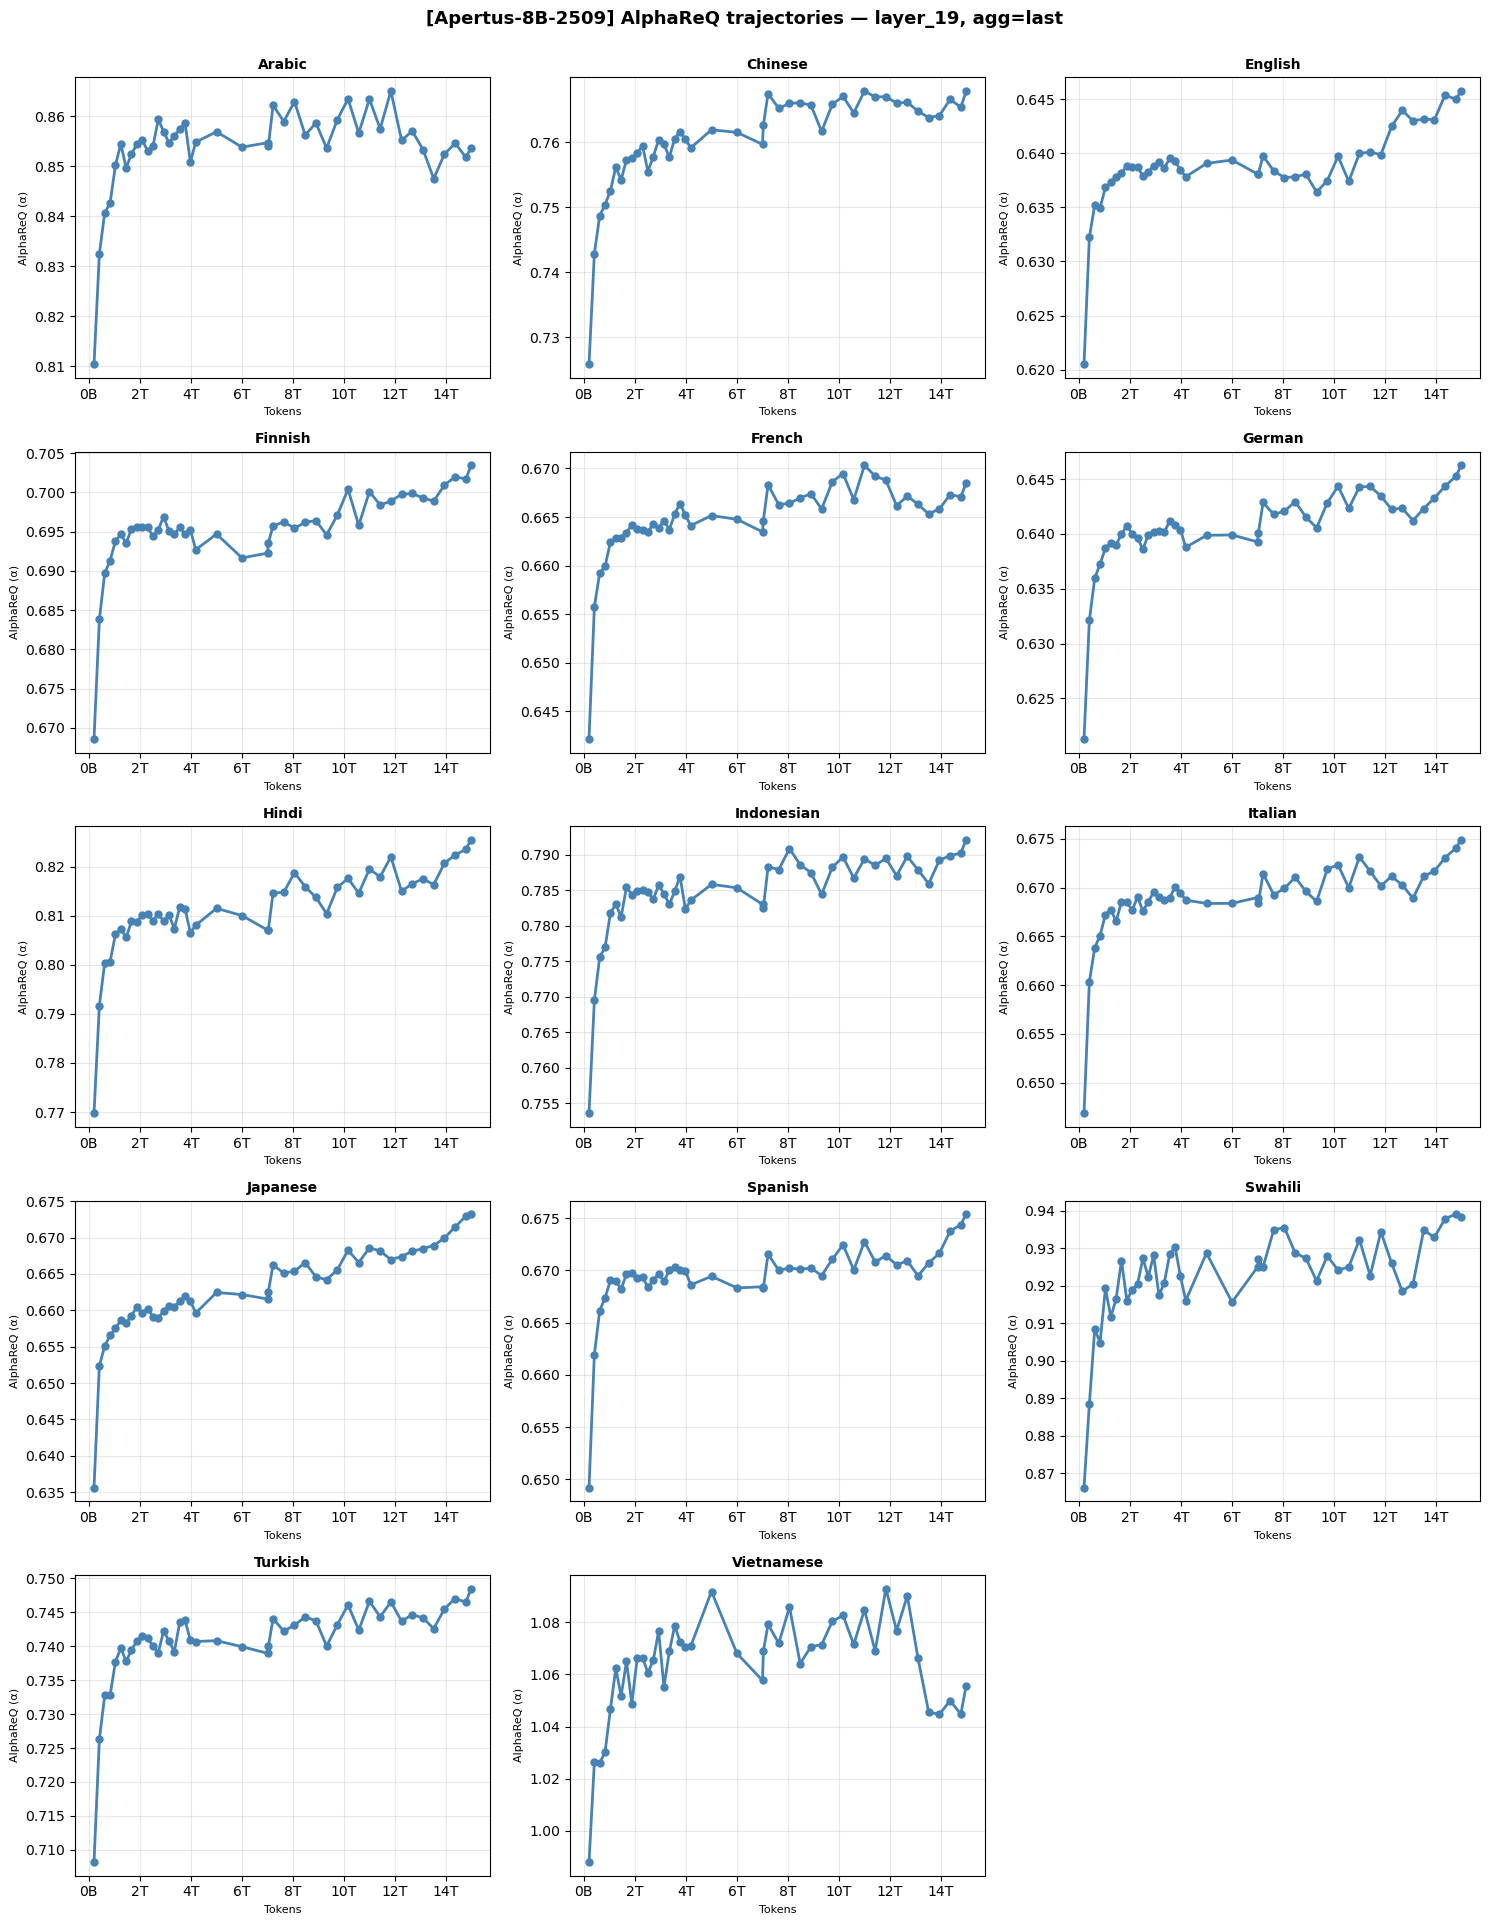

Saved: plots_joao_pinto_407597/alpha_phases_apertus.png


In [7]:
show_alpha_phases(MODELS, data)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task. Grokking onset and peak accuracy serve as the outcome variables for the AlphaReQ correlation analysis.

- **grokking onset (B)** — training token count (in billions) at the first checkpoint where accuracy exceeds the random chance baseline by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **tokens at peak accuracy (B)** — training token count at the checkpoint with the highest observed accuracy.
- **peak accuracy** — highest accuracy observed across all checkpoints.
- **random chance baseline** — expected accuracy for a random classifier (0.25 for 4-way tasks: m-MMLU, Belebele, and M-ARC; 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [8]:
compute_and_show_grokking(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task   language  grokking onset (B)  tokens at peak accuracy (B)  peak accuracy  random chance baseline
  m_mmlu    English                 NaN                        115.0       0.272590                    0.25
  m_mmlu    Chinese                 NaN                        334.0       0.272921                    0.25
  m_mmlu     German                 NaN                        199.0       0.274928                    0.25
  m_mmlu    Spanish                 NaN                        241.0       0.276211                    0.25
  m_mmlu    Italian                 NaN                        415.0       0.275818                    0.25
  m_mmlu     Arabic                 NaN                        531.0       0.273824                    0.25
  m_mmlu      Hindi                 NaN                        210.0       0.269438                    0.25
  m_mmlu Indonesian                 NaN                        115.0       0.

## Overlay Plots

One plot per task, with one panel per language. Each panel shows two y-axes:

- **Left axis (blue)** — AlphaReQ (α) trajectory across all checkpoints.
- **Right axis (red, dashed)** — downstream accuracy across all checkpoints. The axis always spans 0 to 1.

The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, Belebele, and M-ARC; 0.50 for XCOPA). A purple vertical dashed line marks the grokking onset for that language — absent when grokking was not detected.

> **Note:** M-MMLU is selected by default. Use the checkboxes to choose any combination of tasks, then click **Generate plots** to update.

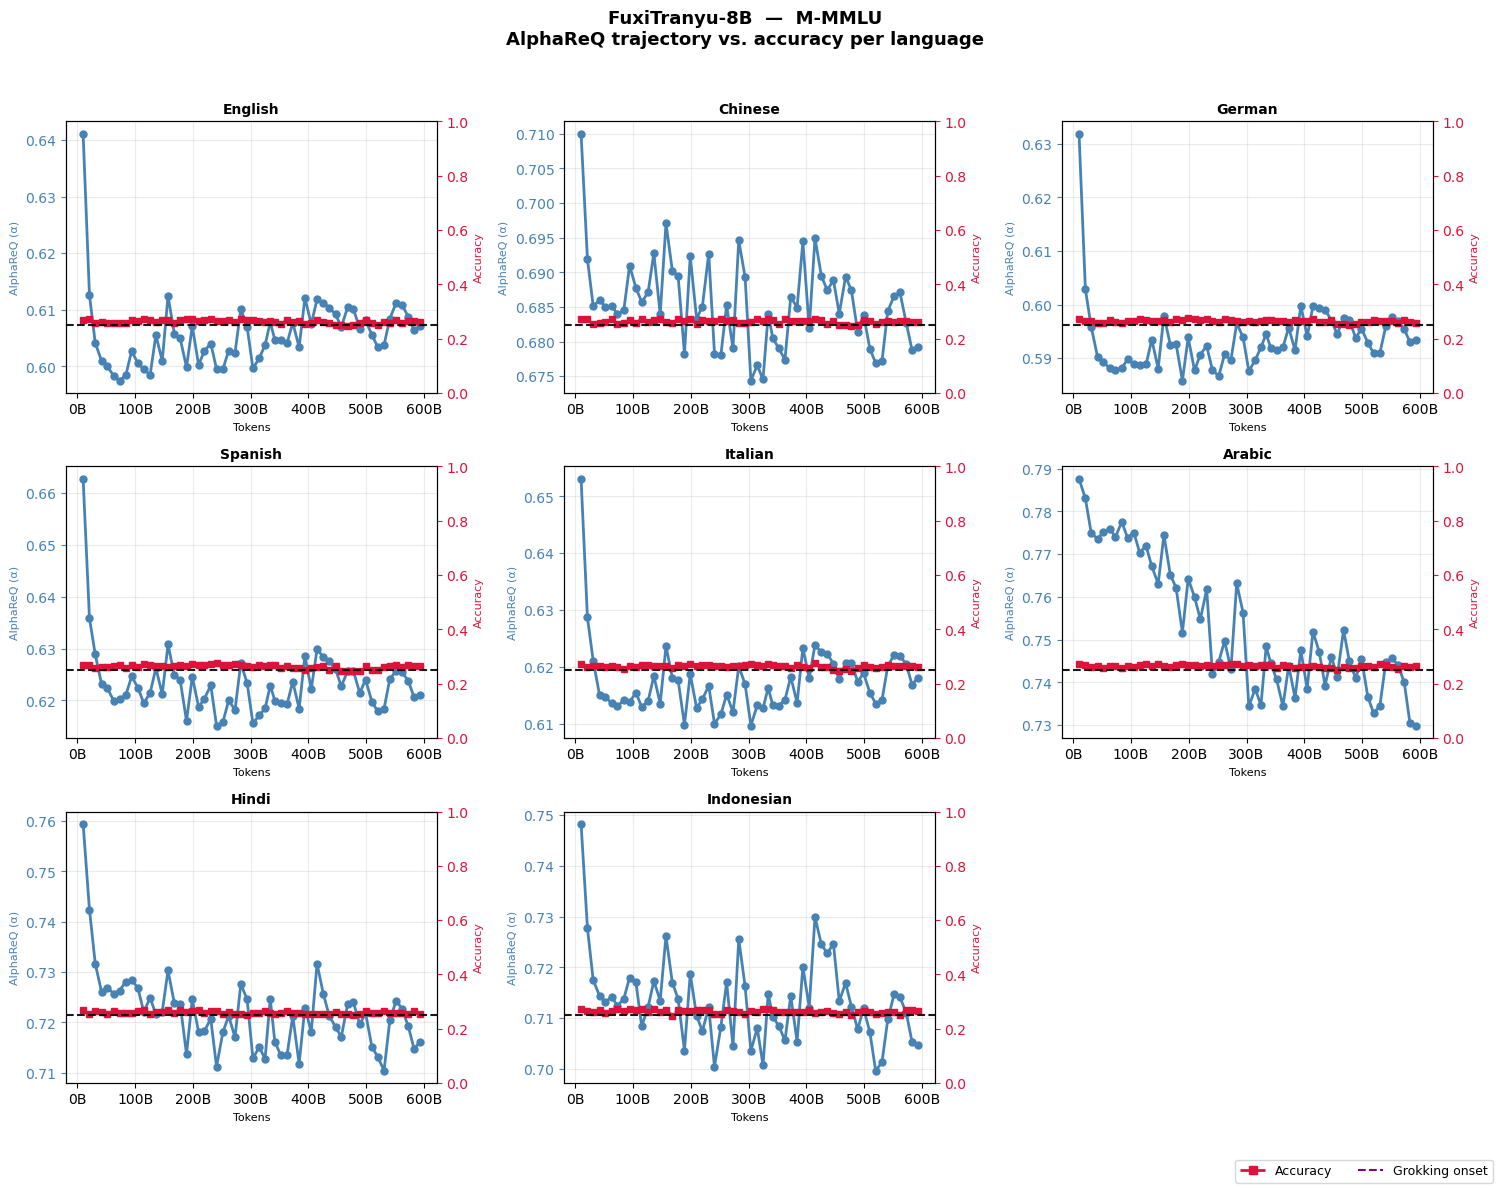

Saved: plots_joao_pinto_407597/alpha_overlay_m_mmlu_fuxi.png


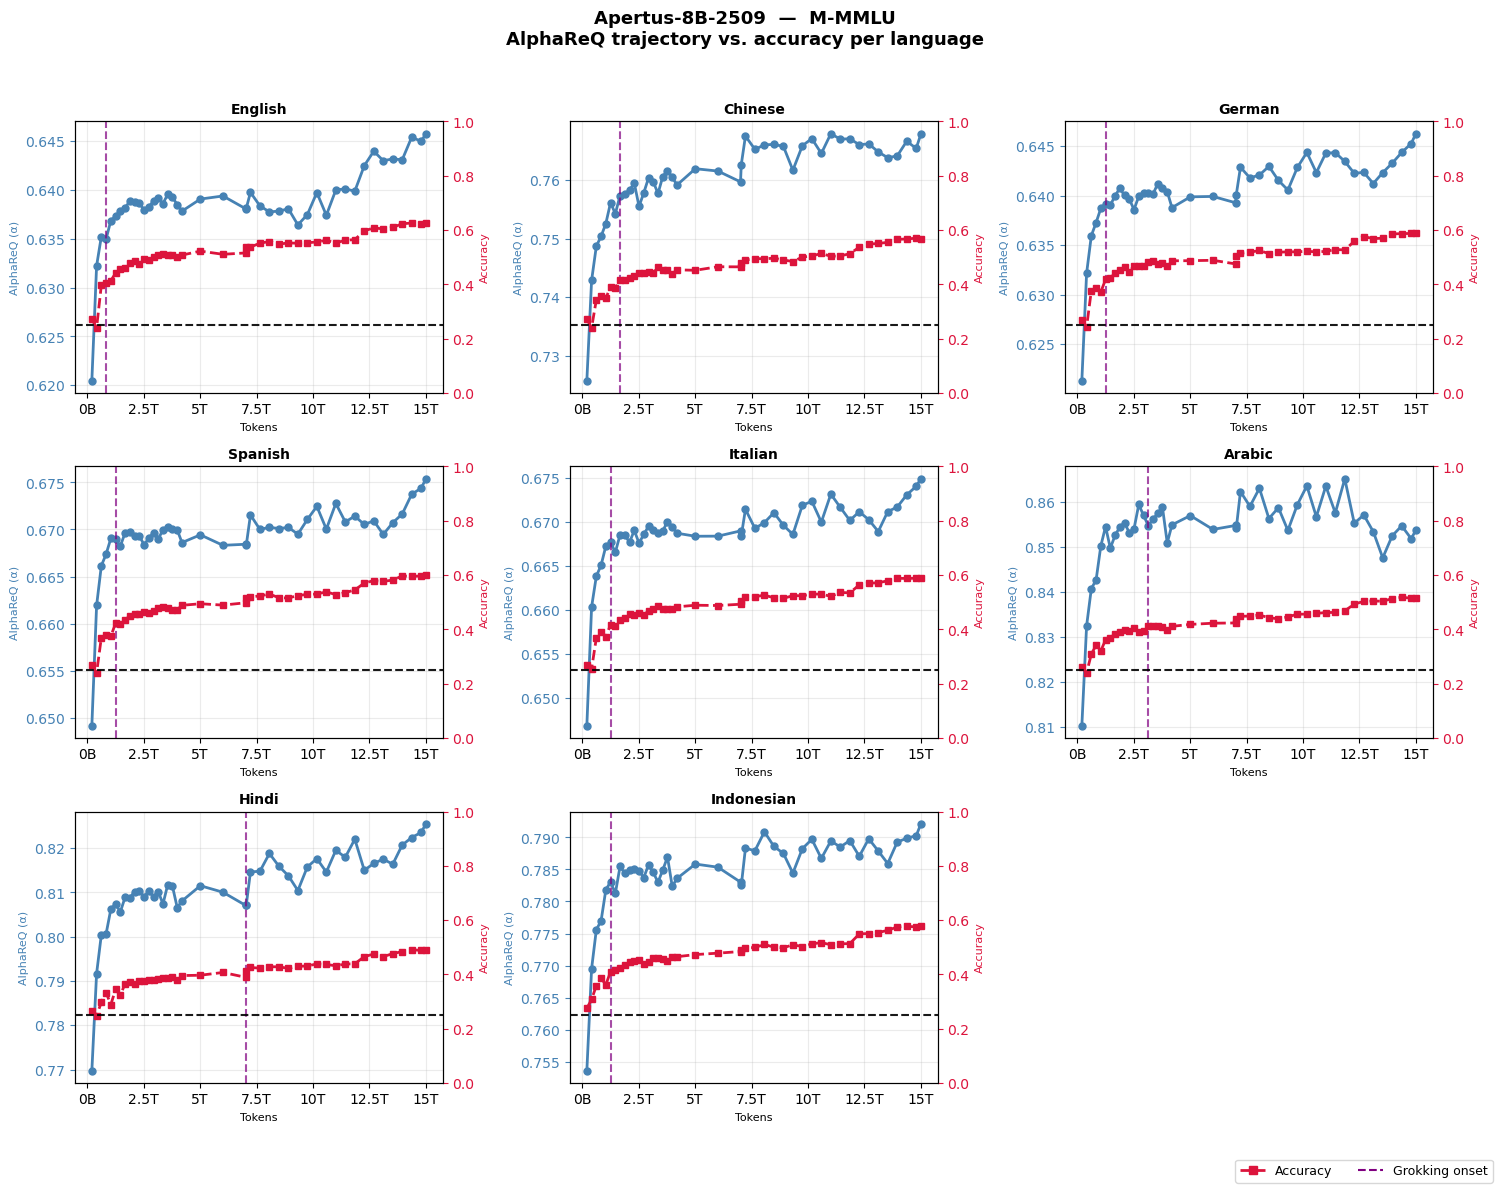

Saved: plots_joao_pinto_407597/alpha_overlay_m_mmlu_apertus.png


In [9]:
show_alpha_overlay_widget(MODELS, data)

## AlphaReQ Geometry–Performance Correlation: Do trajectory features predict grokking onset and peak accuracy?

Tests whether AlphaReQ geometry predicts downstream performance. The predictor set depends on the outcome:

**Grokking onset** uses only **AlphaReQ at first checkpoint** — the single checkpoint guaranteed to be at or before grokking onset in every (model, task, language) combination.

**Peak accuracy** uses all **seven predictors** (retrospective — no leakage risk):
- **AlphaReQ at first checkpoint** — α value at the start of training.
- **AlphaReQ at checkpoint 10** — α value at the 10th checkpoint (the layer-selection horizon).
- **Mean AlphaReQ — first 10 checkpoints** — average α over the first 10 checkpoints (the layer-selection window).
- **Mean AlphaReQ — Q2 (25–50%)** — average α over checkpoints in the second quartile of the token range.
- **Mean AlphaReQ — Q3 (50–75%)** — average α over checkpoints in the third quartile of the token range.
- **Mean AlphaReQ — Q4 (75–100%)** — average α over checkpoints in the last quartile of the token range.
- **AlphaReQ at last checkpoint** — α value at the end of training.

The three quartile windows are non-overlapping by design, ensuring each captures a genuinely distinct phase of training.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [10]:
compute_and_show_alpha_correlations(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task                        predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
  m_mmlu         AlphaReQ at first checkpoint Grokking onset (B)            0         NaN         NaN        NaN        NaN
  m_mmlu         AlphaReQ at first checkpoint      Peak accuracy            8     -0.3095      0.4556    -0.5434     0.1639
  m_mmlu            AlphaReQ at checkpoint 10      Peak accuracy            8     -0.3095      0.4556    -0.5119     0.1947
  m_mmlu Mean AlphaReQ — first 10 checkpoints      Peak accuracy            8     -0.3095      0.4556    -0.5172     0.1893
  m_mmlu          Mean AlphaReQ — Q2 (25–50%)      Peak accuracy            8     -0.3095      0.4556    -0.5394     0.1677
  m_mmlu          Mean AlphaReQ — Q3 (50–75%)      Peak accuracy            8     -0.3095      0.4556    -0.5654     0.1442
  m_mmlu         Mean AlphaReQ — Q4 (75–100%)      Peak accuracy         

### Correlation Heatmap

The table above has rows for each (task × outcome × predictor) combination. The heatmap below condenses all of them into a single 7×8 figure per model (rows = all 7 predictors, columns = tasks × outcomes). Colour encodes Spearman ρ; * marks p < 0.05. Gray cells indicate undefined correlations or predictors not used for that outcome — grokking onset only uses AlphaReQ at first checkpoint, so the remaining 6 predictor rows are gray in all grokking onset columns.

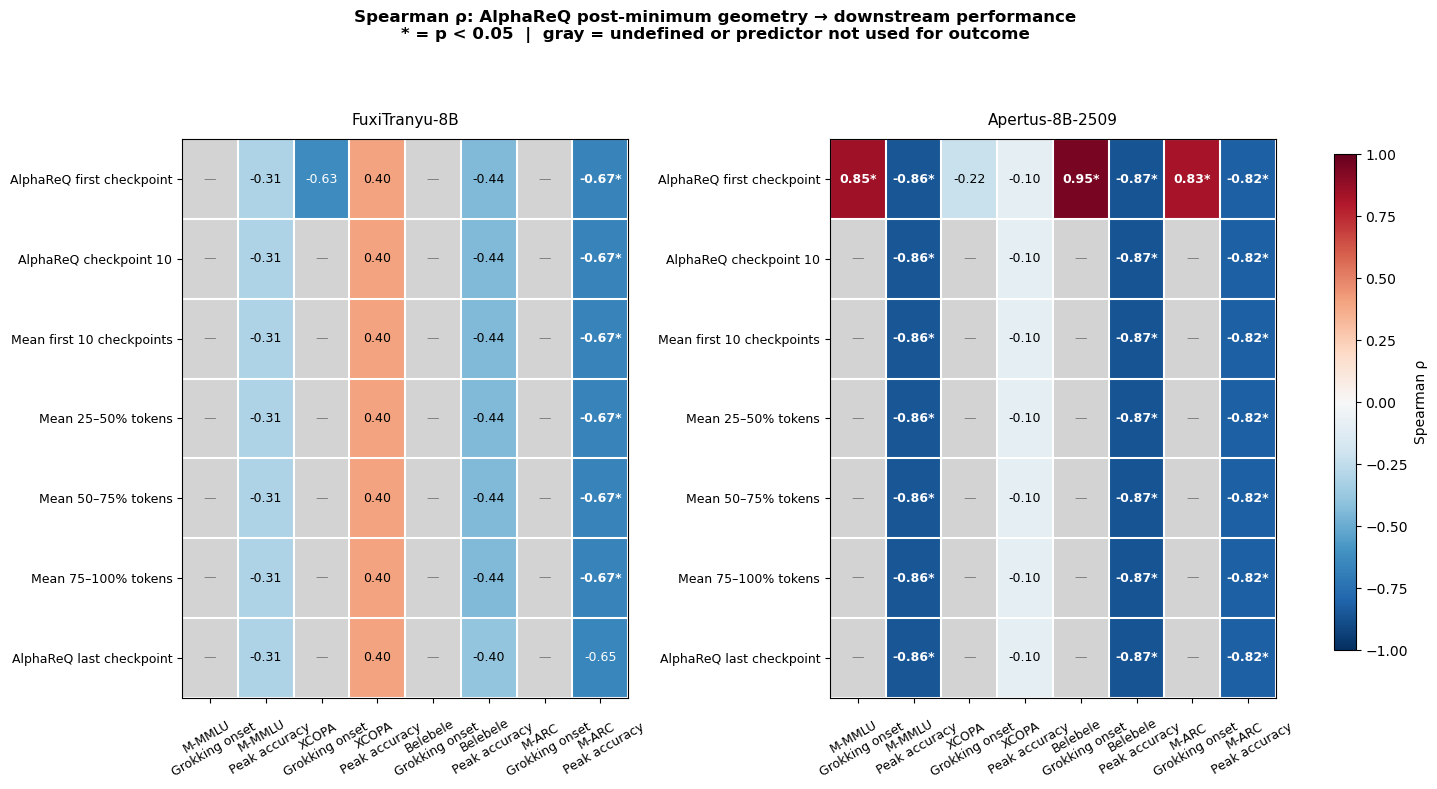

Saved: plots_joao_pinto_407597/alpha_correlation_heatmap.png


In [11]:
show_alpha_correlation_heatmap(MODELS, data)

### Selected Scatter Plot

**AlphaReQ at first checkpoint** is highlighted as the single most interpretable predictor: it requires only one forward pass at the very first checkpoint — no trajectory averaging — and is the only predictor used for grokking onset. The figure shows one row per task (m-MMLU, XCOPA, Belebele, M-ARC) against both outcomes, with per-model regression lines and Spearman/Pearson statistics.

> **What to look for:** For Apertus, a consistent pattern is visible for m-MMLU, Belebele, and M-ARC — languages with lower AlphaReQ at the first checkpoint correlate with earlier grokking onset and higher peak accuracy. XCOPA is the exception: all 5 languages score between 0.702 and 0.784, so outcomes are too tightly clustered to differentiate languages. For Fuxi, m-MMLU and Belebele stay at random chance throughout training, leaving no signal. Only M-ARC shows a meaningful correlation.

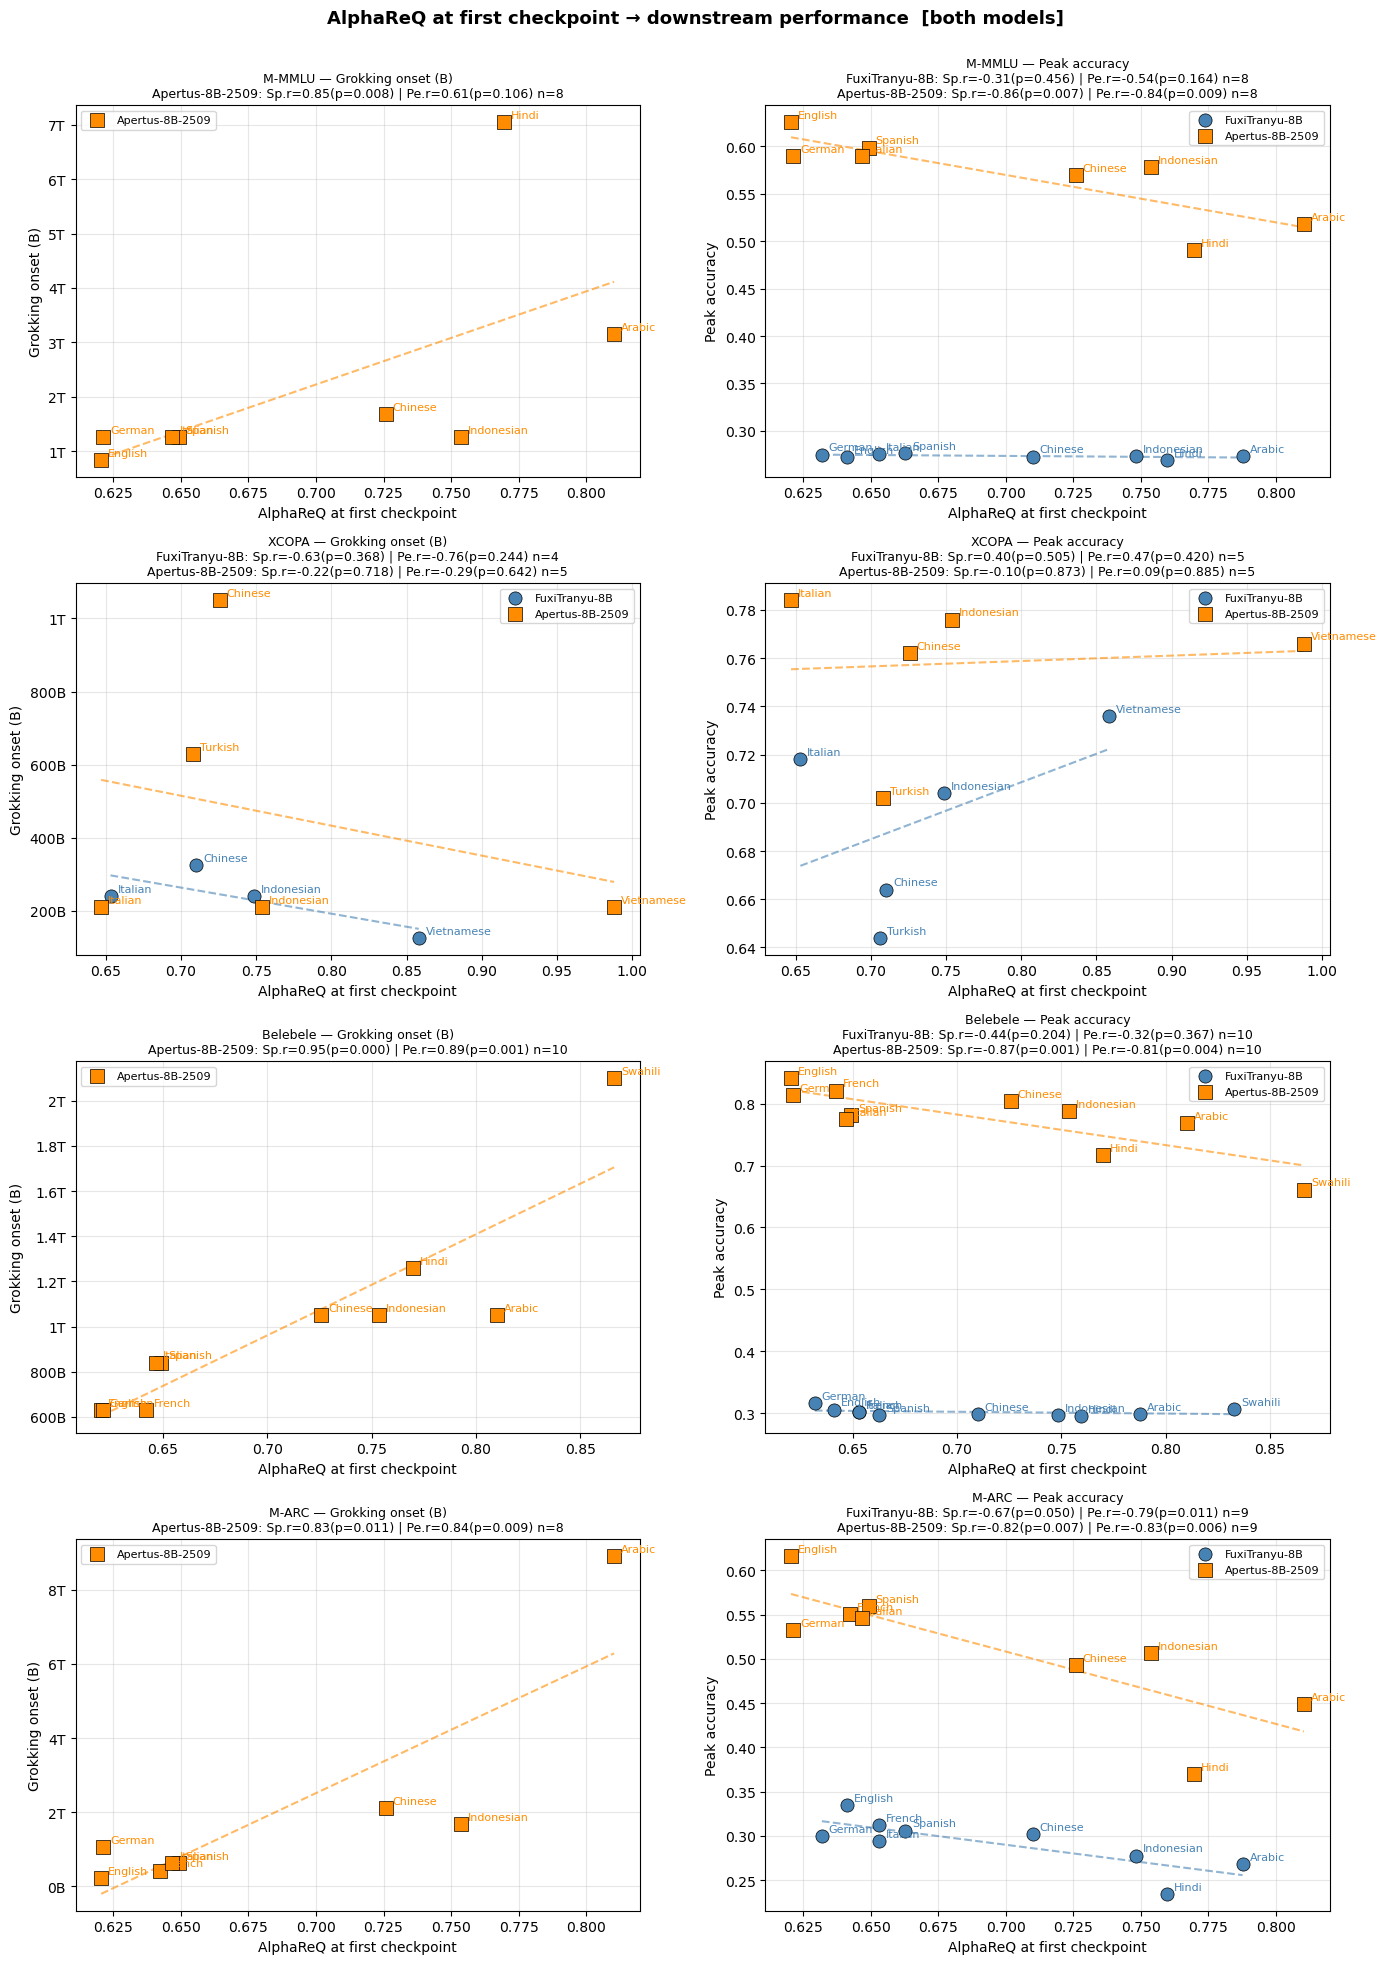

Saved: plots_joao_pinto_407597/scatter_alpha_first.png


In [12]:
show_predictor_scatter(MODELS, data, "alpha_first", "AlphaReQ at first checkpoint",
                       geometry_key="df_alpha_phases")

## AlphaReQ Predictor Analysis Findings

### FuxiTranyu-8B

**m-MMLU** — All 8 languages stay near random chance throughout training. No grokking detected. No predictor is significant (all Sp r = −0.310, p = 0.456 — all 7 predictors yield the same rank ordering of languages, indicating the language hierarchy is stable throughout Fuxi training at this layer).

**XCOPA** — 4 of 5 languages grokked (Turkish did not). Grokking onset (AlphaReQ at first checkpoint, n=4): Sp r = −0.633, p = 0.368 — not significant; with n=4 the minimum exact two-tailed Spearman p-value is ≈ 0.083, so significance is structurally impossible. Peak accuracy: no predictor significant (all Sp r = +0.400, p = 0.505).

**Belebele** — All 10 languages stay near random chance. No grokking detected. No predictor significant (Sp r ≈ −0.439, p = 0.204 for the first 6 predictors; last checkpoint Sp r = −0.396, p = 0.257).

**M-ARC** — No grokking detected. **6 of 7 predictors reach Spearman significance for peak accuracy (Sp r = −0.667, p = 0.050 each)**: AlphaReQ at first checkpoint, checkpoint 10, mean first 10, Q2, Q3, and Q4. All six produce the same rank ordering of languages. AlphaReQ at last checkpoint is marginal but not significant (Sp r = −0.650, p = 0.058). All 7 are significant by Pearson (Pe r ≈ −0.77 to −0.79, all p < 0.02). Direction: lower AlphaReQ is associated with higher M-ARC accuracy throughout training.

---

### Apertus-8B-2509

**m-MMLU** — All 8 languages grokked (840B–7 047B). Grokking onset (AlphaReQ at first checkpoint): **Sp r = +0.850, p = 0.008** — lower AlphaReQ → earlier grokking. Pearson is not significant (p = 0.106). Peak accuracy: **all 7 predictors significant (Sp r = −0.857, p = 0.007 each)**. All 7 predictors produce the same rank ordering of languages — the Apertus language hierarchy by AlphaReQ is stable across all training windows at this layer.

**XCOPA** — All 5 languages grokked. Grokking onset (AlphaReQ at first checkpoint): Sp r = −0.224, p = 0.718 — not significant. Peak accuracy: **no predictor significant** (all Sp r = −0.100, p = 0.873). XCOPA outcomes too tightly clustered (0.702–0.784) for AlphaReQ to differentiate languages.

**Belebele** — All 10 languages grokked (630B–2 100B). **Strongest AlphaReQ–performance relationship in the analysis.** Grokking onset (AlphaReQ at first checkpoint): **Sp r = +0.947, p < 0.001**. Peak accuracy: **all 7 predictors significant (Sp r = −0.867, p = 0.001 each)**.

**M-ARC** — 8 of 9 languages grokked (Hindi did not). Grokking onset (AlphaReQ at first checkpoint, n=8): **Sp r = +0.826, p = 0.011**. Peak accuracy: **all 7 predictors significant (Sp r = −0.817, p = 0.007 each)**.

---

### Cross-model summary

**M-ARC is the only benchmark where AlphaReQ predicts peak accuracy in both models**, with consistent negative direction (lower AlphaReQ → higher accuracy):
- FuxiTranyu-8B: 6 of 7 predictors Spearman-significant (Sp r = −0.667, p = 0.050); all significant by Pearson
- Apertus-8B-2509: all 7 predictors significant (Sp r = −0.817, p = 0.007)

For both models, all significant predictors within each model share the same Sp r — the AlphaReQ language ranking is stable across training windows, so different time windows carry no additional discriminative information.

All other cross-model comparisons fail: Fuxi never learns m-MMLU or Belebele during pre-training (accuracy stays at random chance, no variance to correlate), and XCOPA has no significant AlphaReQ signal in either model.

---

### 💡 Key findings

- **Both models — M-ARC:** lower AlphaReQ at the first checkpoint predicts higher peak accuracy, replicating across both models with the same direction. This mirrors the cross-model M-ARC finding from the RankMe analysis.
- **Apertus — m-MMLU, Belebele, M-ARC:** all 7 AlphaReQ predictors are significant for peak accuracy; grokking onset strongly predicted by AlphaReQ at first checkpoint (Sp r = +0.850, +0.947, and +0.826 respectively) — lower AlphaReQ → earlier grokking.
- **Both models — XCOPA:** no AlphaReQ predictor reaches significance for any outcome.
- **Fuxi — m-MMLU and Belebele:** no signal; accuracy stays at random chance throughout training, leaving no cross-language variance.

## Per-Checkpoint Correlation: Does geometry track the language performance hierarchy over training?

The previous predictor analysis tested whether a single AlphaReQ metric (computed from the full trajectory) predicts a language's final downstream outcome. Here we ask a complementary question: **at each training checkpoint, does the cross-language ranking of AlphaReQ match the cross-language ranking of accuracy at that same checkpoint?**

At any given checkpoint, we have two values per language — AlphaReQ and accuracy on a given task — and we compute **one Spearman correlation** across all languages. Repeating this at every checkpoint produces a curve that answers: **as training progresses, does the model's α geometry become a better or worse predictor of which languages it handles best?**

- A **positive ρ** means languages with higher AlphaReQ also have higher accuracy at that moment.
- A **near-zero ρ** means the two rankings are unrelated — the geometry has no predictive power at that checkpoint.
- **Filled markers** = p < 0.05 (statistically significant); **open markers** = p ≥ 0.05.

In [13]:
compute_and_show_checkpoint_correlations(MODELS, data, metric="alpha_req")


── FuxiTranyu-8B ────────────────────────────────────────
  m_mmlu: 2/57 checkpoints with p<0.05 | max ρ = 0.619 | min ρ = -0.762
  xcopa: 2/57 checkpoints with p<0.05 | max ρ = 0.900 | min ρ = -0.100
  belebele: 3/57 checkpoints with p<0.05 | max ρ = 0.782 | min ρ = -0.821
  m_arc: 35/57 checkpoints with p<0.05 | max ρ = 0.400 | min ρ = -0.900

── Apertus-8B-2509 ────────────────────────────────────────
  m_mmlu: 42/44 checkpoints with p<0.05 | max ρ = -0.167 | min ρ = -0.976
  xcopa: 0/44 checkpoints with p<0.05 | max ρ = 0.700 | min ρ = -0.200
  belebele: 42/44 checkpoints with p<0.05 | max ρ = -0.103 | min ρ = -0.988
  m_arc: 44/44 checkpoints with p<0.05 | max ρ = -0.750 | min ρ = -0.883


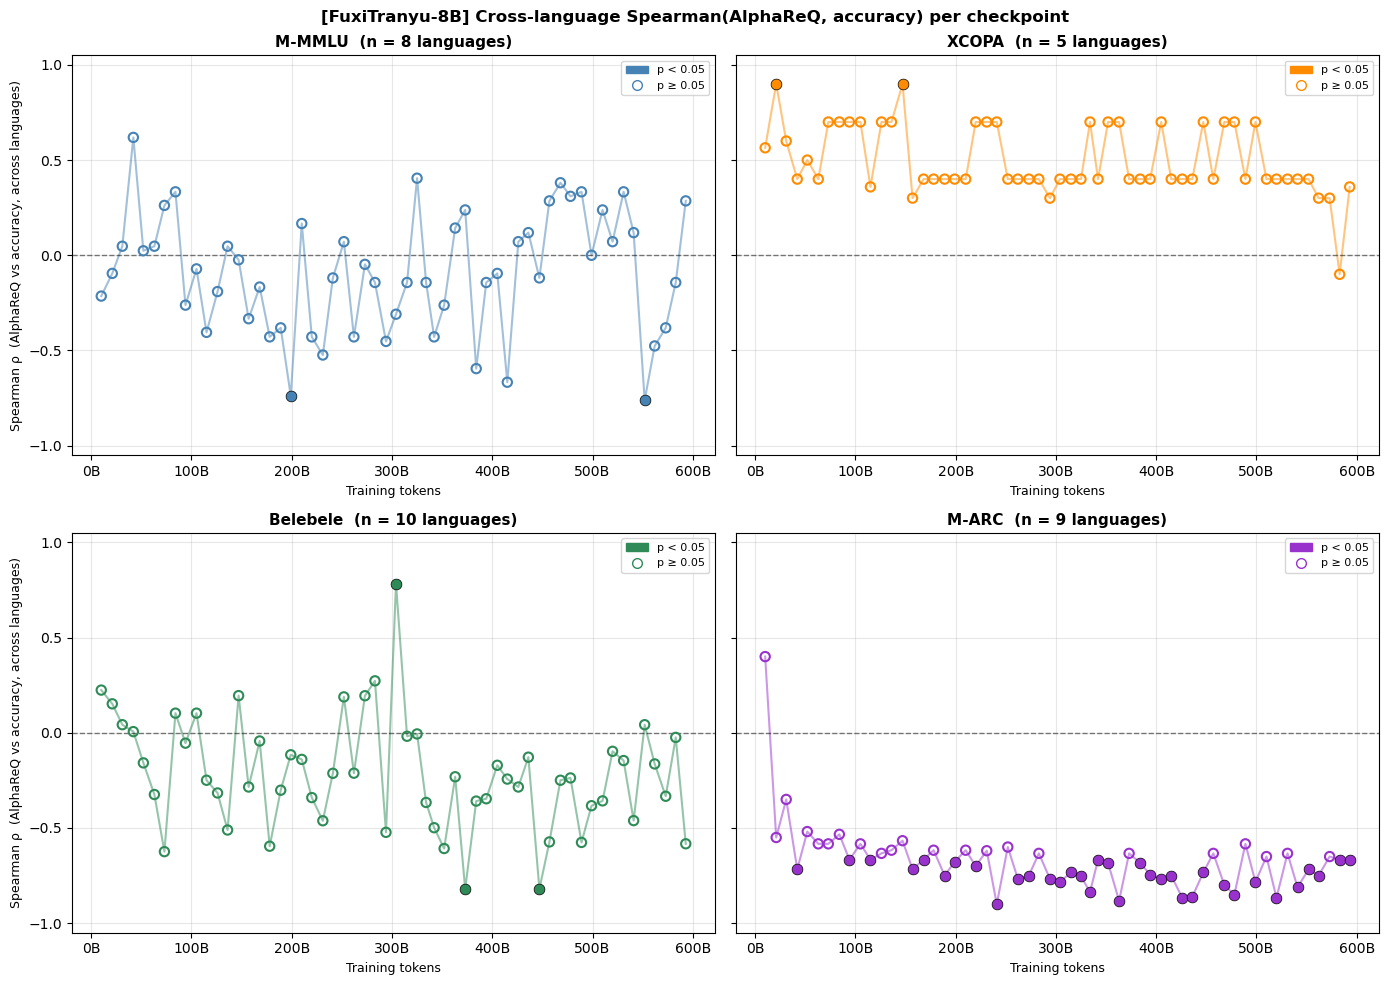

Saved: plots_joao_pinto_407597/alpha_req_checkpoint_correlations_fuxi.png


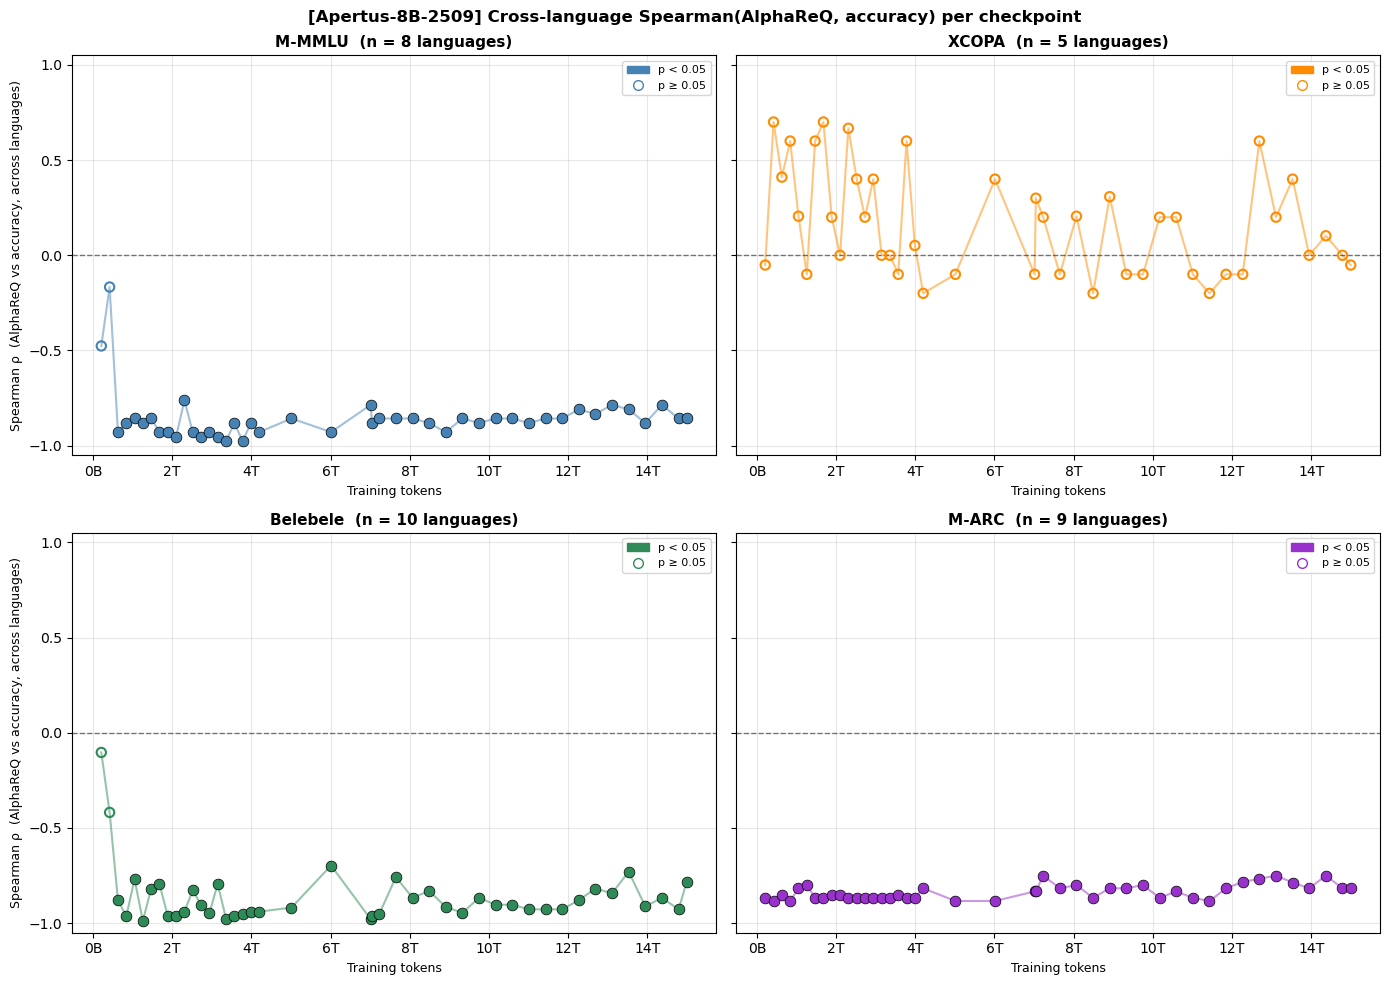

Saved: plots_joao_pinto_407597/alpha_req_checkpoint_correlations_apertus.png


In [14]:
show_checkpoint_correlations(MODELS, data, metric="alpha_req")

## Per-Checkpoint Correlation Findings

### FuxiTranyu-8B

**m-MMLU (8 languages): 2/57 checkpoints significant, max ρ = 0.619, min ρ = −0.762**

Near-zero and mixed-sign correlation throughout training, as expected. All 8 languages stay at random chance (~25%), leaving essentially no accuracy variance. The 2 significant checkpoints are noise.

**XCOPA (5 languages): 2/57 checkpoints significant, max ρ = +0.900, min ρ = −0.100**

Only 2/57 checkpoints significant. This is not an interpretable per-checkpoint signal for XCOPA in FuxiTranyu-8B, but the geometry ranking influences the accuracy ranking in the opposite direction to the M-ARC signal (the only other benchmark with a clear per-checkpoint direction), consistent with the anomaly seen in the RankMe analysis.

**Belebele (10 languages): 3/57 checkpoints significant, max ρ = 0.782, min ρ = −0.821**

Sparse and mixed-sign. All 10 languages stay near random chance throughout training (peak accuracy 0.296–0.317), leaving no meaningful cross-language accuracy variance. The 3 significant checkpoints are isolated and not a sustained pattern.

**M-ARC (9 languages): 35/57 checkpoints significant, max ρ = +0.400, min ρ = −0.900**

The strongest per-checkpoint AlphaReQ result for FuxiTranyu-8B: 35/57 significant checkpoints (61%), and all significant correlations are negative — lower AlphaReQ languages achieve higher M-ARC accuracy.

---

### Apertus-8B-2509

**m-MMLU (8 languages): 42/44 checkpoints significant, max ρ = −0.167, min ρ = −0.976**

Throughout 95% of training, the cross-language AlphaReQ ranking is significantly correlated with the m-MMLU accuracy ranking at that same checkpoint — and **every significant correlation is negative**: lower AlphaReQ → higher accuracy. Even the weakest significant correlation is negative (max ρ = −0.167). This is the AlphaReQ mirror of the RankMe result (40/44 significant, all positive ρ): both metrics encode the same language hierarchy, in opposite directions.

**XCOPA (5 languages): 0/44 checkpoints significant, max ρ = +0.700, min ρ = −0.200**

No significant correlation at any checkpoint. With n=5 languages the critical Spearman ρ for p < 0.05 two-tailed is ≈ 0.900, so the observed maximum ρ = +0.700 cannot reach significance regardless of direction. Consistent with the static predictor analysis where no AlphaReQ predictor reached significance for XCOPA.

**Belebele (10 languages): 42/44 checkpoints significant, max ρ = −0.103, min ρ = −0.988**

95% of checkpoints are significant, and **all correlations are negative** — including the weakest (max ρ = −0.103). The minimum ρ = −0.988 is the strongest per-checkpoint correlation in this notebook. The 2 non-significant checkpoints are the very earliest, before any language has crossed the grokking threshold (all grokk between 630B and 2 100B).

**M-ARC (9 languages): 44/44 checkpoints significant, max ρ = −0.750, min ρ = −0.883**

Every single checkpoint is significant (100%), and **all correlations are strongly negative** — even the weakest is ρ = −0.750. At every training checkpoint, lower AlphaReQ languages have higher M-ARC accuracy. This is the most consistent result in the notebook and replicates the cross-model M-ARC finding from the predictor analysis.

---

### Cross-model summary

**M-ARC is the only benchmark with significant per-checkpoint AlphaReQ correlations in both models** — 35/57 for FuxiTranyu-8B and 44/44 for Apertus-8B-2509 — and the dominant direction is negative in both (lower AlphaReQ → higher M-ARC accuracy). This replicates the per-checkpoint RankMe pattern for M-ARC, where the correlation was positive (higher RankMe → higher M-ARC accuracy): both metrics point to the same underlying language hierarchy, in opposite directions.

All significant Apertus correlations are negative, directly mirroring the RankMe analysis where all significant Apertus correlations were positive. Lower AlphaReQ ↔ higher RankMe ↔ better downstream outcomes.

---

### 💡Key findings

- **Both models — M-ARC:** AlphaReQ is negatively correlated with M-ARC accuracy at most/all checkpoints (35/57 for Fuxi, 44/44 for Apertus), with lower AlphaReQ tracking higher accuracy throughout training.
- **Apertus — m-MMLU and Belebele:** all significant per-checkpoint AlphaReQ correlations are negative (95% of checkpoints).
- **Both models — XCOPA:** no sustained per-checkpoint signal. For Apertus, 0/44 significant — the observed max ρ = +0.700 never reaches the ~0.900 threshold required for n=5. For Fuxi, 2/57 isolated significant checkpoints but no sustained pattern.
- **Fuxi — m-MMLU and Belebele:** no per-checkpoint signal; accuracy stays at random chance throughout training, leaving no cross-language variance to detect.